# Fish Weight Prediction - A regression implementation

In [1]:
%matplotlib inline
# importing dependencies here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

############################################# scikit Learn ###############################

# data split and transformation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler

# pipeline
from sklearn.pipeline import make_pipeline

# model and its evaluation
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

###########################################################################################

# plot
from scipy import stats

# saving the model
from joblib import dump

# formatting
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
# reading the input file
fish_data = pd.read_csv("fish_participant.csv")

<IPython.core.display.Javascript object>

In [3]:
# checking the first 5 records
fish_data.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
1,Perch,110.0,20.0,22.0,23.5,5.5225,3.9950
2,Roach,160.0,20.5,22.5,25.3,7.0334,3.8203
3,Parkki,60.0,14.3,15.5,17.4,6.5772,2.3142
4,Bream,700.0,30.4,33.0,38.3,14.8604,5.2854


<IPython.core.display.Javascript object>

### Exploratory Data Analysis

In [4]:
# checking the data types
fish_data.dtypes

Species     object
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object

<IPython.core.display.Javascript object>

The data types look okay.

In [5]:
# checking for missing values
fish_data.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

<IPython.core.display.Javascript object>

There is no missing data present.

In [6]:
# checking the stats
fish_data.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000
mean,401.676577,26.447748,28.615315,31.422523,9.015701,4.480407
std,338.510755,9.795155,10.498781,11.306311,4.225369,1.696240
min,5.900000,7.500000,8.400000,8.800000,1.738800,1.047600
25%,142.500000,20.000000,22.000000,23.500000,6.138850,3.551400
50%,300.000000,25.400000,27.500000,30.100000,8.145400,4.335000
75%,682.500000,33.750000,36.250000,40.150000,12.143400,5.658300
max,1550.000000,56.000000,60.000000,64.000000,18.957000,8.142000


<IPython.core.display.Javascript object>

For the target variable "Weight", the difference between the min and max value seems to be significantly large. <br>
There could be some outliers present possibly that I will handle later in this code.

In [7]:
# checking for correlations
corr = fish_data.corr()
corr.style.background_gradient(cmap="ocean")

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.900963,0.904090,0.909553,0.738316,0.893379
Length1,0.900963,1.000000,0.999468,0.991363,0.621648,0.862612
Length2,0.904090,0.999468,1.000000,0.993695,0.637353,0.869217
Length3,0.909553,0.991363,0.993695,1.000000,0.702567,0.872672
Height,0.738316,0.621648,0.637353,0.702567,1.000000,0.782936
Width,0.893379,0.862612,0.869217,0.872672,0.782936,1.000000


<IPython.core.display.Javascript object>

All the features are showing strong correlation with the target vaibale weight.<br>
The 3 Length variables are showing collinearity. I will handle this later in this code.

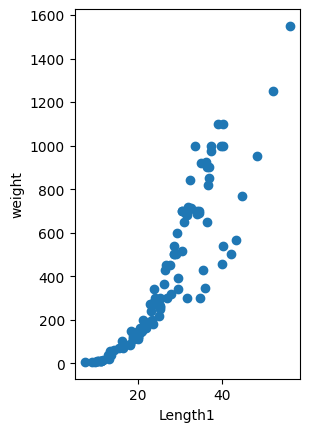

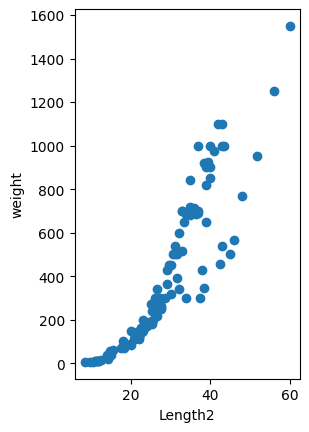

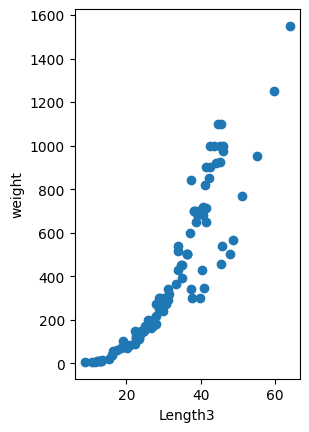

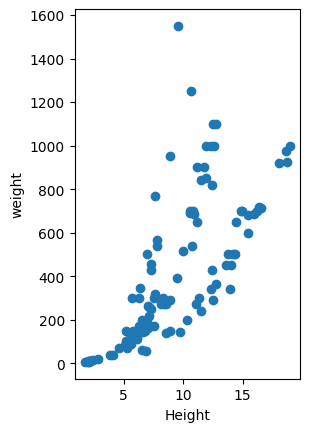

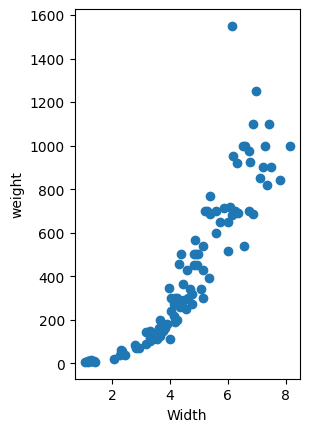

<IPython.core.display.Javascript object>

In [8]:
# checking for linear relationship between features and the target variable

numerical = ["Length1", "Length2", "Length3", "Height", "Width"]

for feature in numerical:
    plt.subplot(1, 2, 1)
    plt.scatter(x=fish_data[feature], y=fish_data["Weight"])
    plt.xlabel(feature)
    plt.ylabel("weight")
    plt.show()

* The relationship between the features and the target variable is not linear. I will be fix this by applying log transformations to the features as well as the target variable through the pipeline.

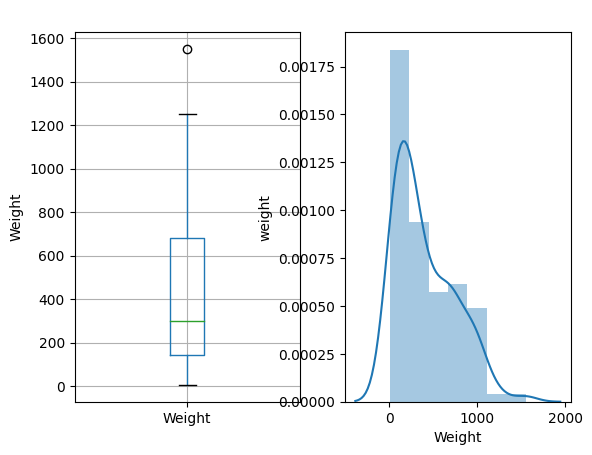

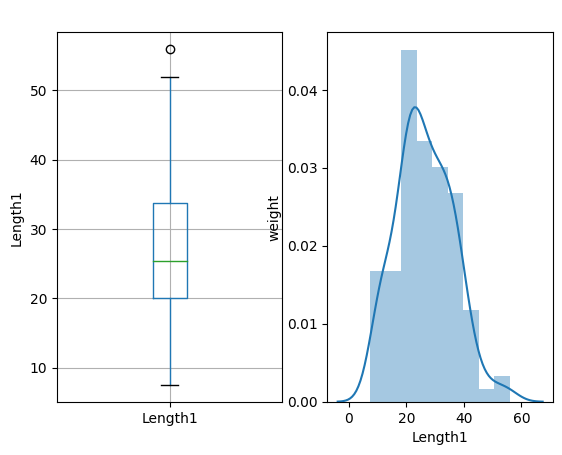

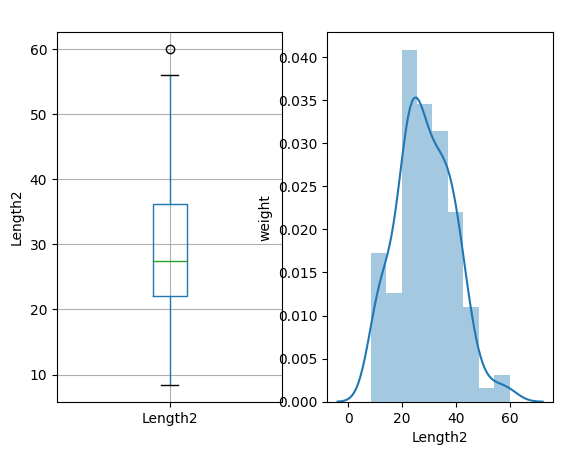

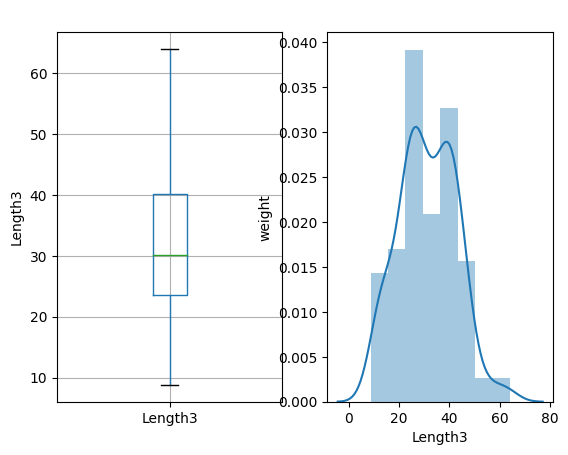

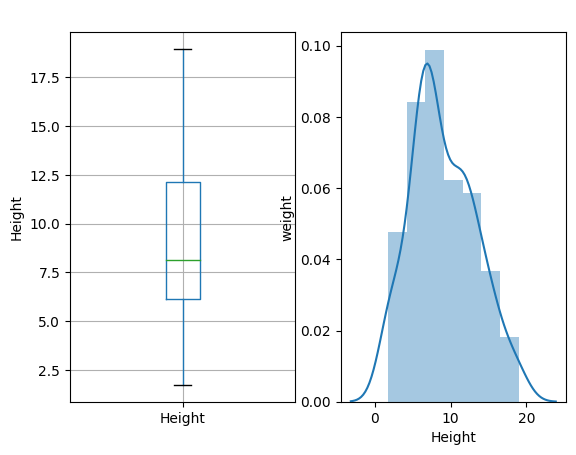

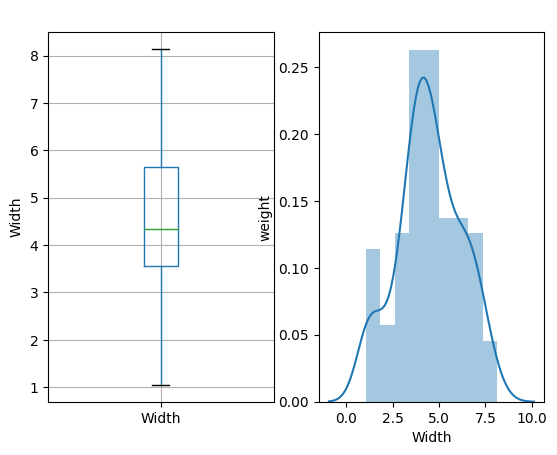

<IPython.core.display.Javascript object>

In [9]:
# checking for outliers and distribution

numerical = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]

for feature in numerical:

    plt.subplot(1, 2, 1)
    fig = fish_data.boxplot(column=feature)
    fig.set_title(" ")
    fig.set_ylabel(feature)

    plt.subplot(1, 2, 2)
    fig = sns.distplot(fish_data[feature])
    fig.set_ylabel("weight")
    fig.set_xlabel(feature)

    plt.show()

There outliers present in target variable "Weight" and features "Lenght1", "Length2". Rest of the data looks good.<br>
The distributions look skewed. 

In [54]:
# finding the outliers
for col in numerical:
    df = fish_data[col]
    df_Q1 = df.quantile(0.25)
    df_Q3 = df.quantile(0.75)
    df_IQR = df_Q3 - df_Q1
    df_lowerend = df_Q1 - (1.5 * df_IQR)
    df_upperend = df_Q3 + (1.5 * df_IQR)

    df_outliers = df[(df < df_lowerend) | (df > df_upperend)]
    print(df_outliers)

13    1550.0
Name: Weight, dtype: float64
13    56.0
Name: Length1, dtype: float64
13    60.0
Name: Length2, dtype: float64
Series([], Name: Length3, dtype: float64)
Series([], Name: Height, dtype: float64)
Series([], Name: Width, dtype: float64)


<IPython.core.display.Javascript object>

Record at row # 13 seems to be the outlier for weight, lenght1 and length2. <br>
Dropping this record from the dataset.

In [55]:
# dropping the outlier at row # 13
fish_data = fish_data.drop([13])

<IPython.core.display.Javascript object>

#### Temporarily applying log transformations just to show how it will normalize the distributions of features and the target variable to some extent.
* Note that I have not transformed the actual features/target yet in the dataset. 

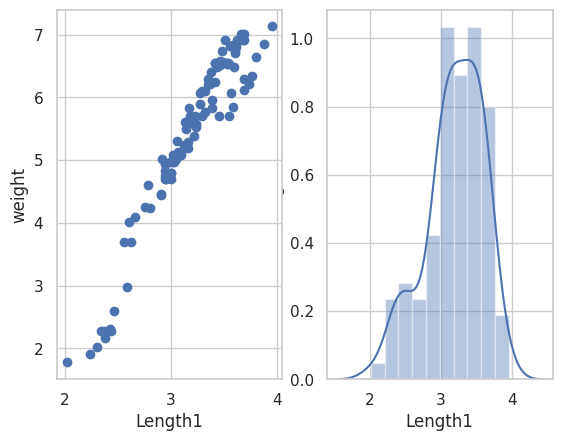

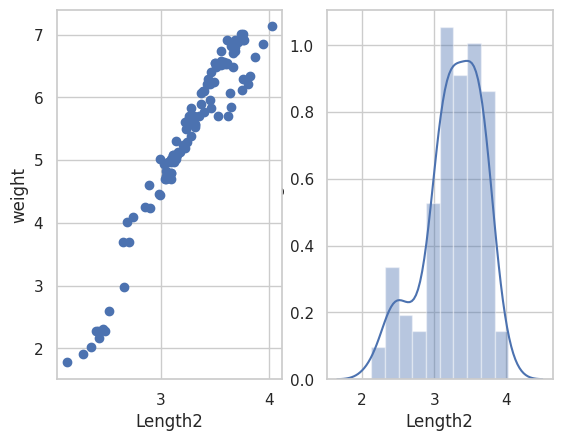

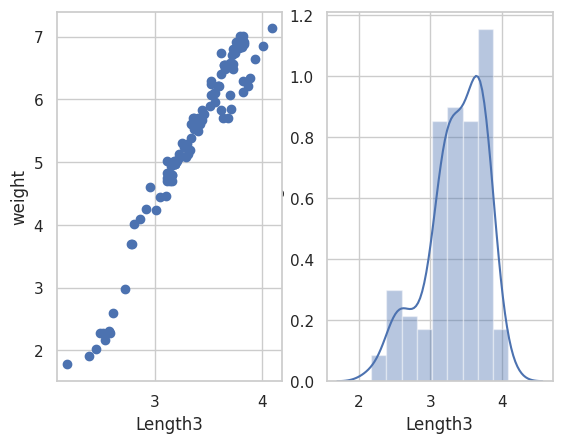

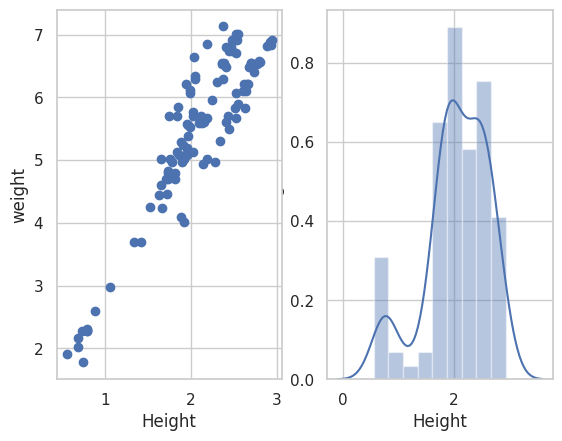

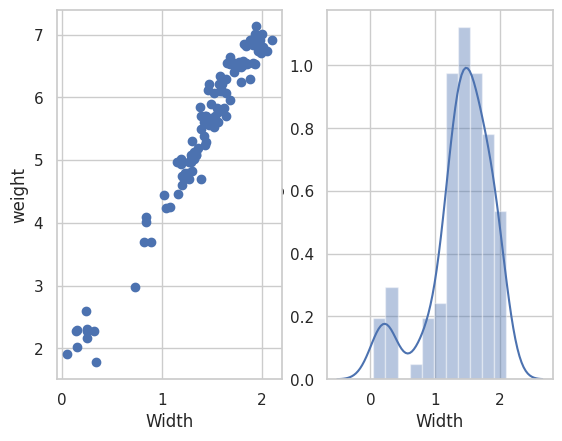

<IPython.core.display.Javascript object>

In [56]:
# rechecking the linear relationships and distributions

numerical = ["Length1", "Length2", "Length3", "Height", "Width"]

for feature in numerical:

    plt.subplot(1, 2, 2)
    fig = sns.distplot(np.log(fish_data[feature]))
    fig.set_ylabel("weight")
    fig.set_xlabel(feature)

    plt.subplot(1, 2, 1)
    plt.scatter(x=np.log(fish_data[feature]), y=np.log(fish_data["Weight"]))
    plt.xlabel(feature)
    plt.ylabel("weight")
    plt.show()

    plt.show()

The linear relationship between the features and the target variable looks better now. <br>
The distributions are still a little skewed but for I will move ahead with this. 

Perch        39
Bream        24
Roach        14
Pike         11
Smelt        10
Parkki        8
Whitefish     4
Name: Species, dtype: int64


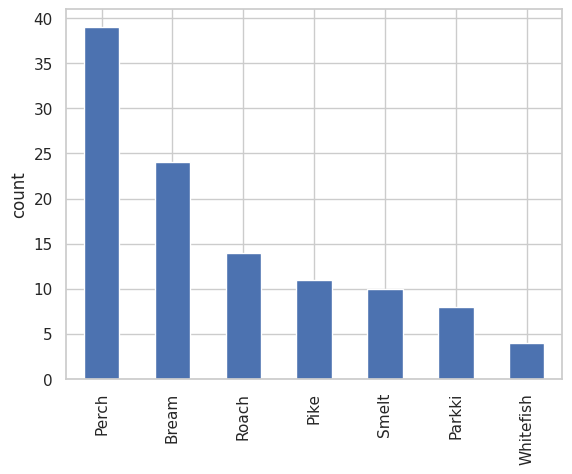

<IPython.core.display.Javascript object>

In [57]:
# checking the categorical feature - Species
print(fish_data["Species"].value_counts())
fish_data["Species"].value_counts().plot(kind="bar")
plt.ylabel("count")
plt.show()

This catgorical feature will need encoding. I will handle this using OneHotEncoder later in this code. 

In [58]:
# checking for collinerity between the 3 length variables
fish_data[["Length1", "Length2", "Length3", "Weight"]].corr()

,Length1,Length2,Length3,Weight
Length1,1.000000,0.999424,0.990713,0.891403
Length2,0.999424,1.000000,0.993216,0.895063
Length3,0.990713,0.993216,1.000000,0.901948
Weight,0.891403,0.895063,0.901948,1.000000


<IPython.core.display.Javascript object>

The 3 lenght variables are highly correlated. Let's check their values.

In [59]:
fish_data[["Length1", "Length2", "Length3"]].head(10)

,Length1,Length2,Length3
0,26.5,29.0,34.0
1,20.0,22.0,23.5
2,20.5,22.5,25.3
3,14.3,15.5,17.4
4,30.4,33.0,38.3
5,13.8,15.0,16.0
6,30.4,33.0,38.5
7,25.4,27.5,28.9
8,9.3,9.8,10.8
9,23.2,25.4,30.0


<IPython.core.display.Javascript object>

Since Length3 values are the highest for each row, it is probably the Total Length of the fish. <br>
So keeping Length3 and dropping the other two length variables from the dataset. 

In [60]:
fish_data = fish_data.drop(["Length1", "Length2"], axis=1)

<IPython.core.display.Javascript object>

### Model Creation

In [61]:
# dividing the data into features and target variable
X = fish_data.drop("Weight", axis=1)
y = fish_data["Weight"]

<IPython.core.display.Javascript object>

In [62]:
# for encoding the categorical feature - species and for transforming the numerical features using log transformation

numerical = ["Length3", "Height", "Width"]
categorical = ["Species"]

preprocesser = ColumnTransformer(
    transformers=[
        ("one_hot_encoder", OneHotEncoder(), categorical),
        ("log_transformer", FunctionTransformer(np.log, validate=False), numerical,),
    ],
    remainder="passthrough",
)

<IPython.core.display.Javascript object>

In [63]:
# splitting the data into train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

<IPython.core.display.Javascript object>

### Linear Regression

In [64]:
# building the pipeline
lr_pipe = make_pipeline(
    preprocesser,
    TransformedTargetRegressor(
        regressor=LinearRegression(), func=np.log, inverse_func=np.exp
    ),
)

# fitting the data
lr_pipe.fit(X_train, y_train)

# predicting
y_predict = lr_pipe.predict(X_test)

<IPython.core.display.Javascript object>

* Note that I have to reapply the log transformation to get the plot for transformed target variable. 

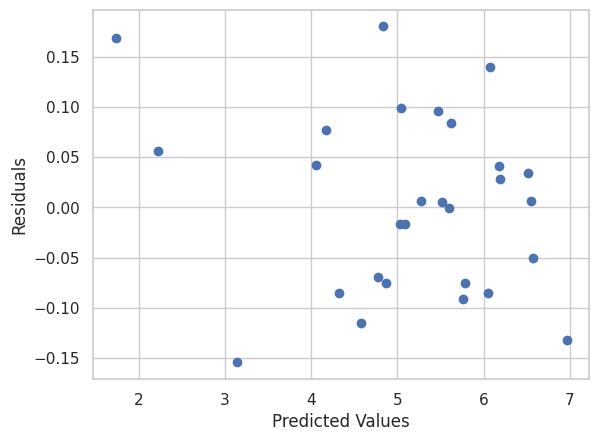

<IPython.core.display.Javascript object>

In [65]:
# Residual Plot
plt.scatter(np.log(y_predict), np.log(y_test) - np.log(y_predict))
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

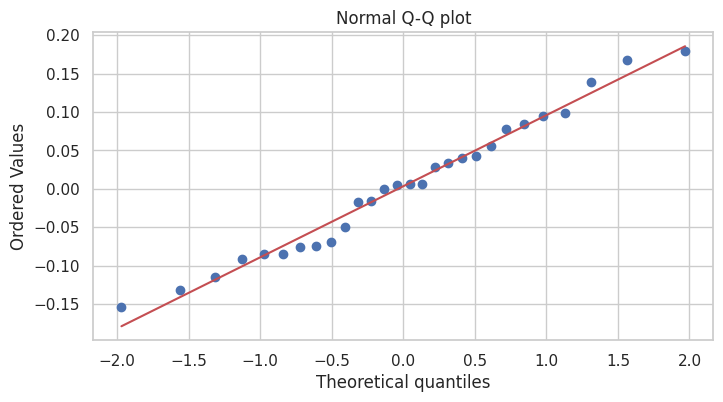

<IPython.core.display.Javascript object>

In [66]:
# Normal Q-Q plot
sns.set(style="whitegrid")
plt.figure(figsize=(8, 4))
stats.probplot(np.log(y_test) - np.log(y_predict), dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

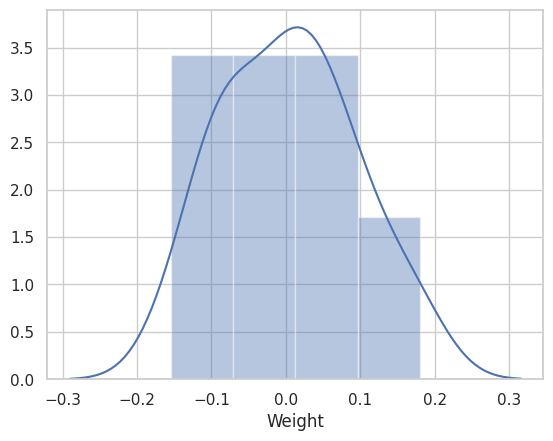

<IPython.core.display.Javascript object>

In [67]:
# distplot
sns.distplot(np.log(y_test) - np.log(y_predict))

In [68]:
# Test MSE and R2
print(f"\nLinear Regression Test MSE: {mean_squared_error(y_test, y_predict)}")
print(f"Linear Regression Test Accuracy (R-Squared): {r2_score(y_test, y_predict)}")


# cross validation score
cv_score = np.mean(
    (cross_val_score(lr_pipe, X, y, cv=5, scoring="neg_mean_squared_error")) * -1
)
print(f"\nLinear Regression Cross Validation Score: {cv_score}")


Linear Regression Test MSE: 1023.7636893532998
Linear Regression Test Accuracy (R-Squared): 0.9820780111246777

Linear Regression Cross Validation Score: 2217.9015265675757


<IPython.core.display.Javascript object>

### Lasso

In [69]:
import warnings

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

# building lasso pipeline
lasso_pipe = make_pipeline(preprocesser, StandardScaler(), Lasso())

parameters = {
    "lasso__alpha": [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40]
}

lasso_regressor = TransformedTargetRegressor(
    GridSearchCV(lasso_pipe, parameters, scoring="neg_mean_squared_error", cv=5),
    func=np.log,
    inverse_func=np.exp,
)

lasso_regressor.fit(X_train, y_train)

TransformedTargetRegressor(func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>,
                           regressor=GridSearchCV(cv=5,
                                                  estimator=Pipeline(steps=[('columntransformer',
                                                                             ColumnTransformer(remainder='passthrough',
                                                                                               transformers=[('one_hot_encoder',
                                                                                                              OneHotEncoder(),
                                                                                                              ['Species']),
                                                                                                             ('log_transformer',
                                                                                                              FunctionTransformer(func=<ufunc 

<IPython.core.display.Javascript object>

In [70]:
print(lasso_regressor.regressor_.best_params_)
print(lasso_regressor.regressor_.best_score_)

prediction_lasso = lasso_regressor.predict(X_test)

{'lasso__alpha': 0.001}
-0.010462517081477527


<IPython.core.display.Javascript object>

* Note that I have to reapply the log transformation to get the plot for transformed target variable. 

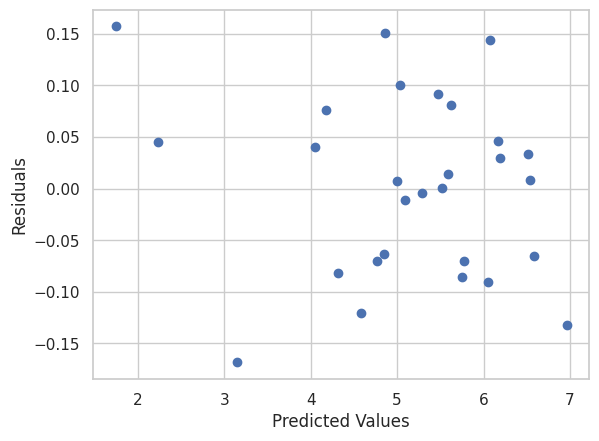

<IPython.core.display.Javascript object>

In [71]:
# Lasso Residual Plot
plt.scatter(np.log(prediction_lasso), np.log(y_test) - np.log(prediction_lasso))
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

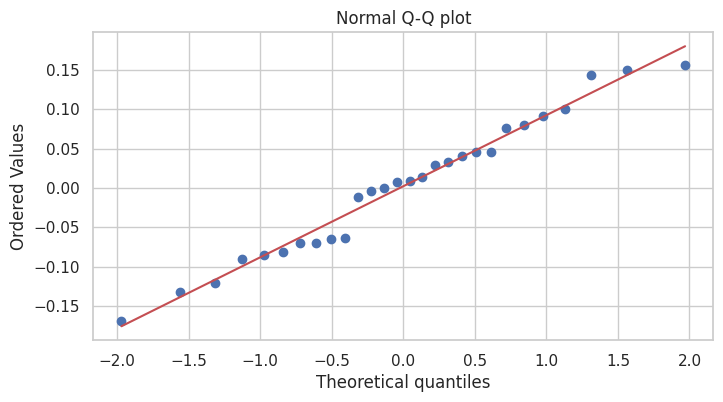

<IPython.core.display.Javascript object>

In [72]:
# Lasso Normal Q-Q plot
sns.set(style="whitegrid")

plt.figure(figsize=(8, 4))
stats.probplot(np.log(y_test) - np.log(prediction_lasso), dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

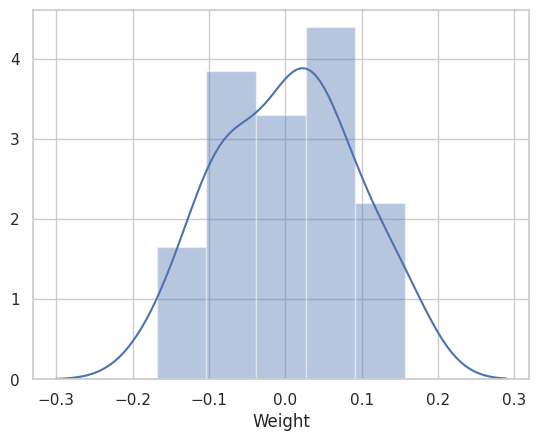

<IPython.core.display.Javascript object>

In [73]:
# distplot
sns.distplot(np.log(y_test) - np.log(prediction_lasso))

In [74]:
# # MSE for test data
print("Lasso Test MSE:", mean_squared_error(y_test, prediction_lasso))

# R2 for test data
print(
    "\nLasso Test Accuracy (R-Squared):", r2_score(y_test, prediction_lasso),
)

# cross validation score
cv_score = np.mean(
    (cross_val_score(lasso_regressor, X, y, cv=5, scoring="neg_mean_squared_error"))
    * -1
)
print("\nLasso Cross Validation Score:", cv_score)

Lasso Test MSE: 1053.3297395919487

Lasso Test Accuracy (R-Squared): 0.9815604283768475

Lasso Cross Validation Score: 2204.0598271684985


<IPython.core.display.Javascript object>

### Random Forest

In [75]:
# building random forest pipeline
rf_pipe = make_pipeline(
    preprocesser,
    TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=10),
        func=np.log,
        inverse_func=np.exp,
    ),
)

# fitting the data
rf_pipe.fit(X_train, y_train)

# predicting
rf_predictions = rf_pipe.predict(X_test)

<IPython.core.display.Javascript object>

* Note that I have to reapply the log transformation to get the plot for transformed target variable. 

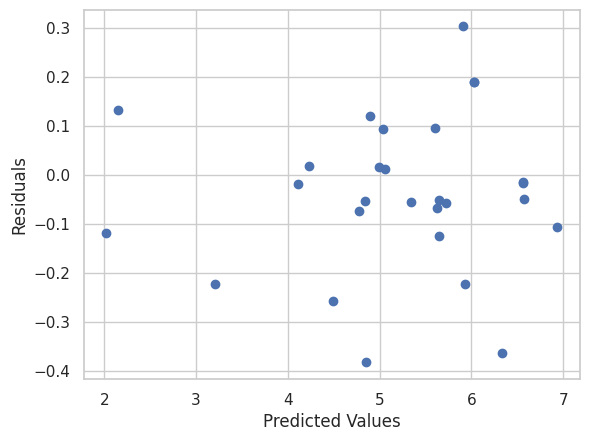

<IPython.core.display.Javascript object>

In [76]:
# Random Forest Residual Plot
plt.scatter(np.log(rf_predictions), np.log(y_test) - np.log(rf_predictions))
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

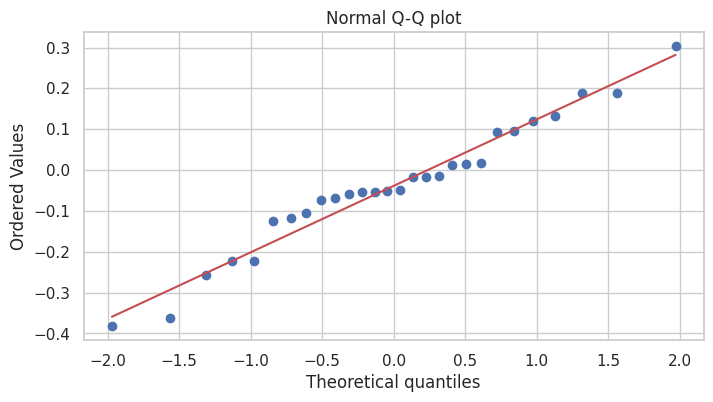

<IPython.core.display.Javascript object>

In [77]:
# Random Forest Normal Q-Q plot
sns.set(style="whitegrid")

plt.figure(figsize=(8, 4))
stats.probplot(np.log(y_test) - np.log(rf_predictions), dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

In [78]:
# test MSE
print(f"Random Forest Test MSE: {mean_squared_error(y_test, rf_predictions)}")

# test R2
print(f"Random Forest Test Accuracy: {r2_score(y_test, rf_predictions)}")

# cross validation score
cv_score = np.mean(
    (cross_val_score(rf_pipe, X, y, cv=5, scoring="neg_mean_squared_error")) * -1
)
print(f"Random Forest Cross Validation Score: {cv_score}")

Random Forest Test MSE: 3010.6320787677614
Random Forest Test Accuracy: 0.9472959285580367
Random Forest Cross Validation Score: 4568.815194954668


<IPython.core.display.Javascript object>

Random Forest didn't do very well for this dataset as compared to the Linear and Lasso Models. 

### Selecting Linear Regression as the final model for this dataset. Lasso model has the smallest CV MSE but the difference with Linear Regression MSE was insignificant. So I decided to go with the simpler LR Model for this dataset. 

In [79]:
# retraining the LR model on entire dataset
lr_pipe.fit(X, y)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one_hot_encoder',
                                                  OneHotEncoder(),
                                                  ['Species']),
                                                 ('log_transformer',
                                                  FunctionTransformer(func=<ufunc 'log'>),
                                                  ['Length3', 'Height',
                                                   'Width'])])),
                ('transformedtargetregressor',
                 TransformedTargetRegressor(func=<ufunc 'log'>,
                                            inverse_func=<ufunc 'exp'>,
                                            regressor=LinearRegression()))])

<IPython.core.display.Javascript object>

### Saving the final model

In [80]:
dump(lr_pipe, "reg_notebook_model.joblib")

['reg_notebook_model.joblib']

<IPython.core.display.Javascript object>